# Introduction
This project involves forecasting real-world time series data using both traditional and modern approaches. We model quarterly sales from Johnson & Johnson and Amazon's share prices using ARMA and RNN-based models (LSTM, GRU). The goal is to evaluate and compare forecast performance across methods for a 24-month prediction horizon.

In [2]:
# loading required librarues and the dataset

import pandas as pd
import matplotlib.pyplot as plt
jj_df = pd.read_csv('jj.csv', header=0, parse_dates=[0], index_col=0)
display(jj_df)

,data
date,
1960-01-01,0.71
1960-04-01,0.63
1960-07-02,0.85
1960-10-01,0.44
1961-01-01,0.61
...,...
1979-10-01,9.99
1980-01-01,16.20
1980-04-01,14.67


In [3]:
# Renaming the column for clarity
jj_df.columns = ['sales']


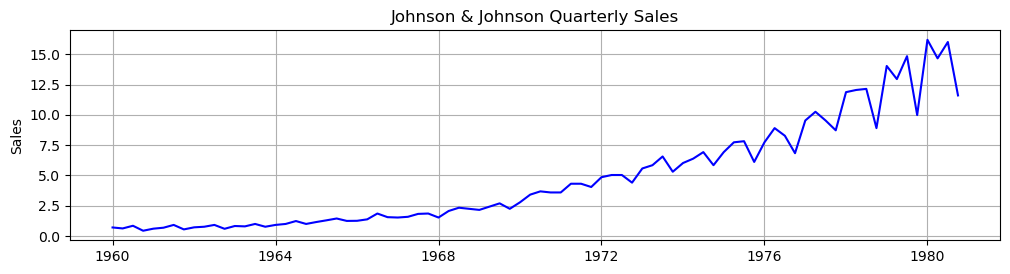

In [4]:
# Plotting
plt.figure(figsize=(12, 6))

# Line plotting of sales data
plt.subplot(2, 1, 1)
plt.plot(jj_df['sales'], color='blue')
plt.title('Johnson & Johnson Quarterly Sales')
plt.ylabel('Sales')
plt.grid(True)


The sales data from 1960 to 1980 shows a clear upward trend, indicating consistent growth over time. This suggests that Johnson & Johnson experienced steady business expansion during this period.

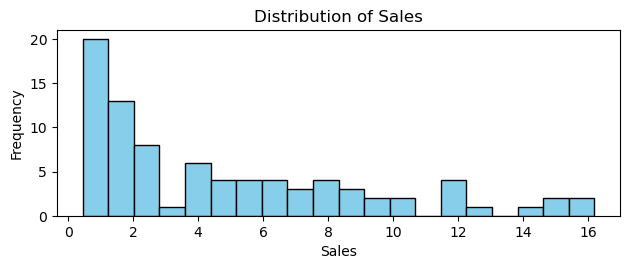

In [6]:
# Plotting of sales values
plt.subplot(2, 1, 2)
plt.hist(jj_df['sales'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Checking for stationarity

In [8]:
from statsmodels.tsa.stattools import adfuller
# 1. Rolling statistics
rolling_mean = jj_df['sales'].rolling(window=8).mean()
rolling_std = jj_df['sales'].rolling(window=8).std()
print(rolling_mean)

date
1960-01-01         NaN
1960-04-01         NaN
1960-07-02         NaN
1960-10-01         NaN
1961-01-01         NaN
                ...   
1979-10-01    12.10500
1980-01-01    12.64500
1980-04-01    12.97125
1980-07-02    13.45500
1980-10-01    13.79250
Name: sales, Length: 84, dtype: float64


In [9]:
print(rolling_std)

date
1960-01-01         NaN
1960-04-01         NaN
1960-07-02         NaN
1960-10-01         NaN
1961-01-01         NaN
                ...   
1979-10-01    1.954709
1980-01-01    2.424040
1980-04-01    2.508235
1980-07-02    2.693564
1980-10-01    2.158794
Name: sales, Length: 84, dtype: float64


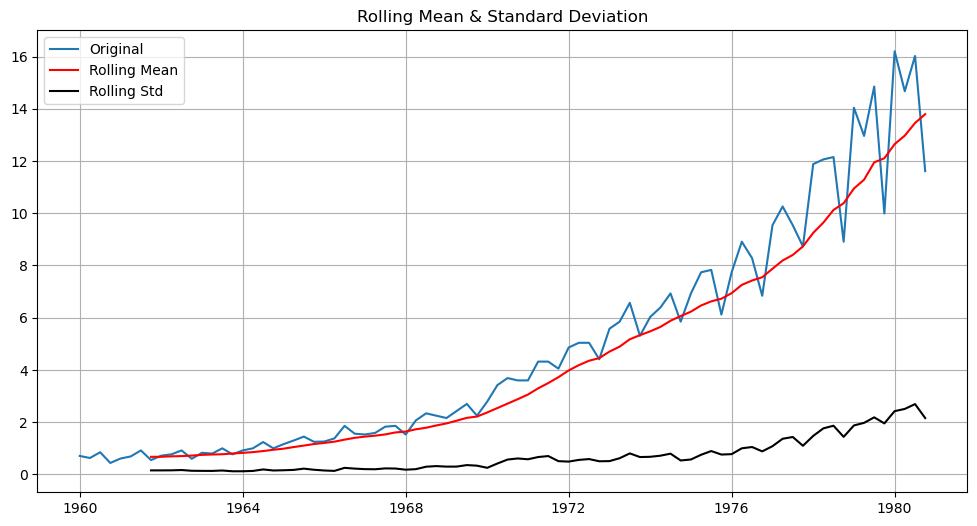

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(jj_df['sales'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean', color='red')
plt.plot(rolling_std, label='Rolling Std', color='black')
plt.title('Rolling Mean & Standard Deviation')
plt.legend()
plt.grid(True)
plt.show()

### Perfoming augmented dickey-fuller test

In [12]:
adf_result = adfuller(jj_df['sales'])

print('ADF Statistic: %f' % adf_result[0])
print('p-value: %f' % adf_result[1])
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'   {key}: {value:.3f}')

ADF Statistic: 2.742017
p-value: 1.000000
Critical Values:
   1%: -3.525
   5%: -2.903
   10%: -2.589


From the result, we found that the p-value is greater than 0.05 abd therefore, we fail to reject the null hypothesis and conclude that the data is not stationary.

## Performing Log Transformation

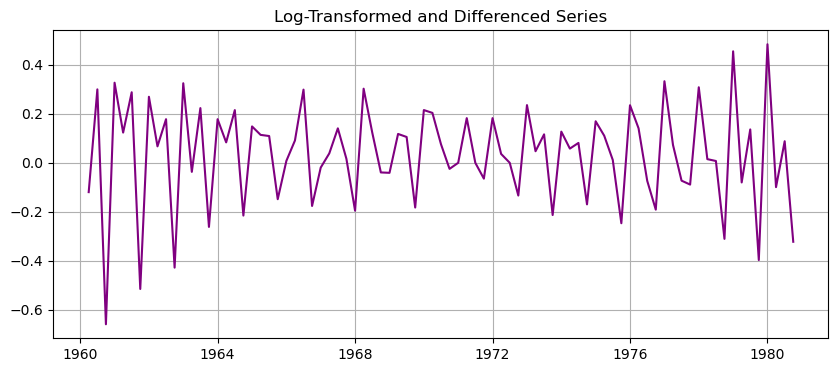

In [15]:
import numpy as np
# Log transformation
jj_log = np.log(jj_df['sales'])

# First differencing
jj_log_diff = jj_log.diff().dropna()


# Plotting the transformed series
plt.figure(figsize=(10, 4))
plt.plot(jj_log_diff, color='purple')
plt.title('Log-Transformed and Differenced Series')
plt.grid(True)
plt.show()

In [16]:
# ADF Testing on transformed series
adf_result_diff = adfuller(jj_log_diff)
print('ADF Statistic (log-diff): %f' % adf_result_diff[0])
print('p-value: %f' % adf_result_diff[1])
print('Critical Values:')
for key, value in adf_result_diff[4].items():
    print(f'   {key}: {value:.3f}')

ADF Statistic (log-diff): -4.317044
p-value: 0.000415
Critical Values:
   1%: -3.518
   5%: -2.900
   10%: -2.587


After applying a log transformation and first differencing, the ADF test statistic is -4.32 with a p-value of 0.0004. This is well below the 1% critical value (-3.518), indicating strong evidence against the null hypothesis. Therefore, the transformed series is stationary and suitable for ARIMA modelling.

## The autocorrelation function

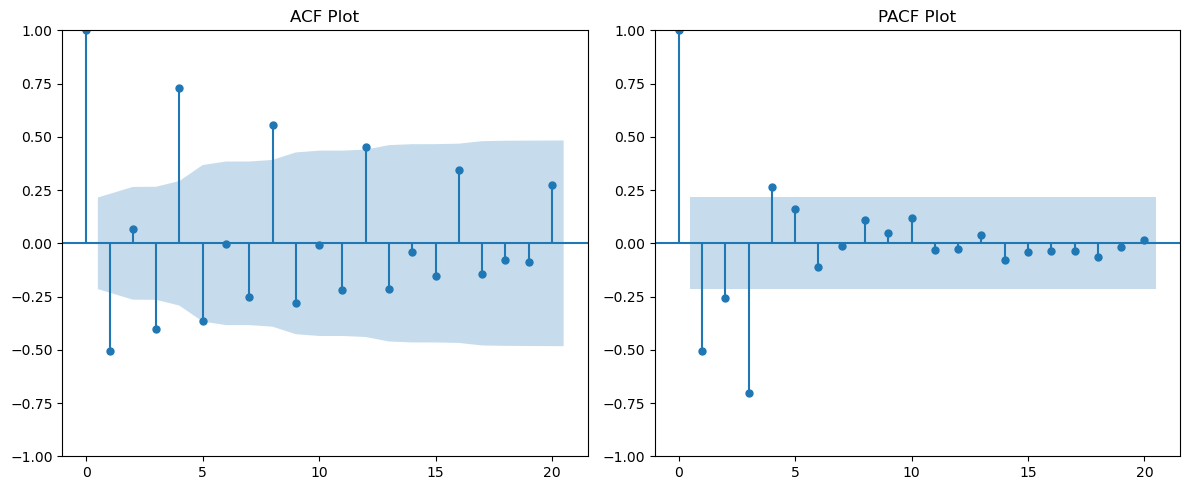

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF and PACF plots of the log-differenced data
plt.figure(figsize=(12, 5))
plt.subplot(121)
plot_acf(jj_log_diff.dropna(), lags=20, ax=plt.gca())
plt.title('ACF Plot')

plt.subplot(122)
plot_pacf(jj_log_diff.dropna(), lags=20, ax=plt.gca(), method='ywm')
plt.title('PACF Plot')

plt.tight_layout()
plt.show()

In [20]:
import warnings
import itertools
import statsmodels.api as sm
#Turning off warnings from convergence issues
warnings.filterwarnings("ignore")
# Defining p and q ranges
p = q = range(0, 5)
pdq = list(itertools.product(p, [1], q))  # d = 1


# Grid searching to find best ARIMA(p,1,q) based on AIC
aic_values = []
best_aic = float("inf")
best_order = None

for order in pdq:
    try:
        model = sm.tsa.ARIMA(jj_log, order=order)
        model_fit = model.fit()
        aic = model_fit.aic
        aic_values.append((order, aic))
        if aic < best_aic:
            best_aic = aic
            best_order = order
    except:
        continue

print(f'Best ARIMA order: {best_order} with AIC: {best_aic:.2f}')

Best ARIMA order: (4, 1, 3) with AIC: -144.20


In [21]:
## Fitting the model

# Fitting the  final model with best (p,d,q)
final_model = sm.tsa.ARIMA(jj_log, order=best_order)
final_model_fit = final_model.fit()

# Summary of the model
print(final_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   84
Model:                 ARIMA(4, 1, 3)   Log Likelihood                  80.099
Date:                Mon, 14 Apr 2025   AIC                           -144.198
Time:                        03:05:10   BIC                           -124.847
Sample:                             0   HQIC                          -136.423
                                 - 84                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0005      0.060     -0.009      0.993      -0.118       0.116
ar.L2          0.0137      0.049      0.279      0.780      -0.083       0.110
ar.L3          0.0272      0.048      0.565      0.5

The optimal ARIMA model selected using AIC is ARIMA(4,1,3), with an AIC of -144.2. Key coefficients such as AR(4), MA(1), and MA(3) are statistically significant. Residual diagnostics indicate no autocorrelation or non-normality, suggesting a well-fitted model.

## Evaluating model performance (RMSE, residual plots)

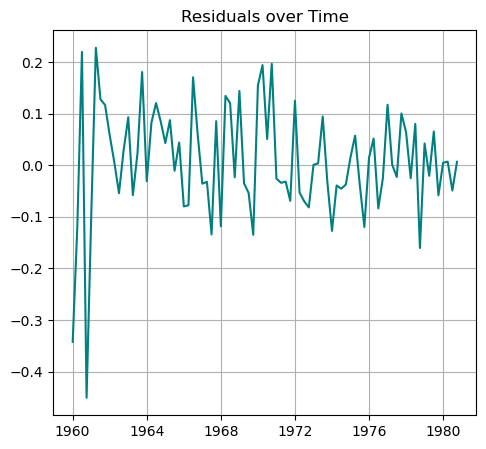

In [24]:
from sklearn.metrics import mean_squared_error
# 1. Plotting residuals
residuals = final_model_fit.resid

plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.plot(residuals, color='teal')
plt.title('Residuals over Time')
plt.grid(True)



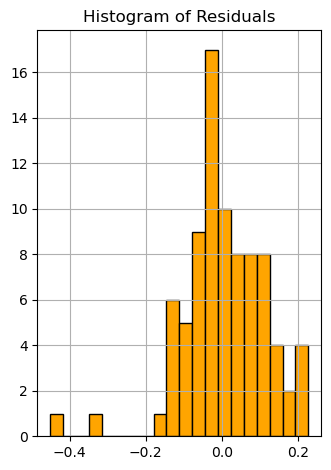

In-sample RMSE: 0.1034


In [25]:
plt.subplot(122)
plt.hist(residuals, bins=20, color='orange', edgecolor='black')
plt.title('Histogram of Residuals')
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Calculating RMSE
predictions = final_model_fit.predict(start=1, end=len(jj_log)-1)
true_values = jj_log[1:]
rmse = np.sqrt(mean_squared_error(true_values, predictions))

print(f'In-sample RMSE: {rmse:.4f}')

## Forecasting for the next 24-hours

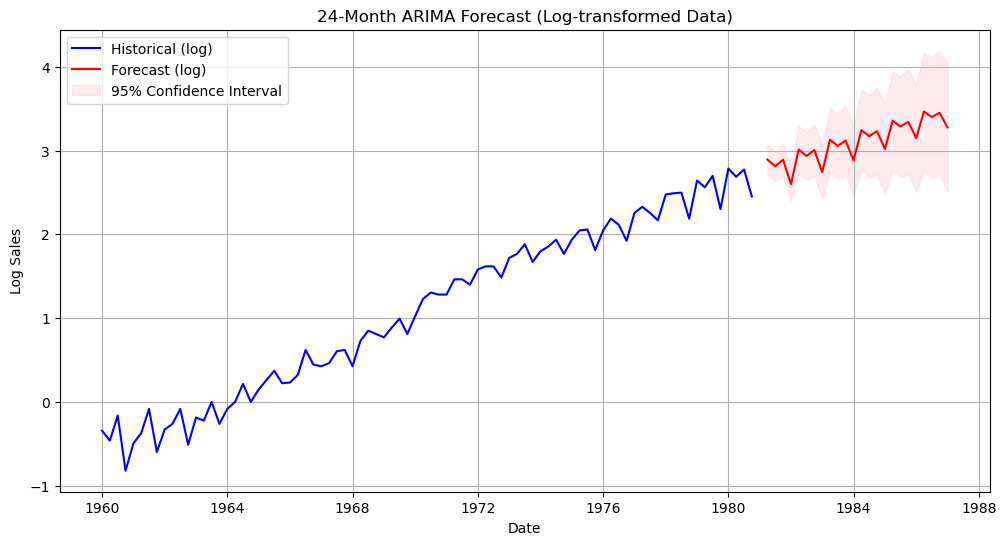

In [27]:
# Forecasting 24 steps ahead
forecast_steps = 24
forecast = final_model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()
# Building time index for future dates
future_index = pd.date_range(start=jj_log.index[-1], periods=forecast_steps + 1, freq='Q')[1:]

# Plotting the data and forecast
plt.figure(figsize=(12, 6))
plt.plot(jj_log, label='Historical (log)', color='blue')
plt.plot(future_index, forecast_mean, label='Forecast (log)', color='red')
plt.fill_between(future_index, 
                 forecast_ci.iloc[:, 0], 
                 forecast_ci.iloc[:, 1], 
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('24-Month ARIMA Forecast (Log-transformed Data)')
plt.xlabel('Date')
plt.ylabel('Log Sales')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, GRU


data = jj_df.values.astype("float32")

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
# Creatng sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(scaled_data, seq_length)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Train/test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Building and train LSTM model
lstm_model = Sequential([LSTM(50, activation='relu', input_shape=(seq_length, 1)), Dense(1)])
lstm_model.compile(optimizer='adam', loss='mse')
history_lstm = lstm_model.fit(X_train, y_train, epochs=50, batch_size=4, validation_data=(X_test, y_test), verbose=0)

# Building and train GRU model
gru_model = Sequential([GRU(50, activation='relu', input_shape=(seq_length, 1)), Dense(1)])
gru_model.compile(optimizer='adam', loss='mse')
history_gru = gru_model.fit(X_train, y_train, epochs=50, batch_size=4, validation_data=(X_test, y_test), verbose=0)

# Predicting and inverse transform
lstm_pred = scaler.inverse_transform(lstm_model.predict(X_test))
gru_pred = scaler.inverse_transform(gru_model.predict(X_test))
y_test_inv = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step


LSTM RMSE: 2.1490607
LSTM MAE: 1.9624919
GRU RMSE: 3.159249
GRU MAE: 2.6379812


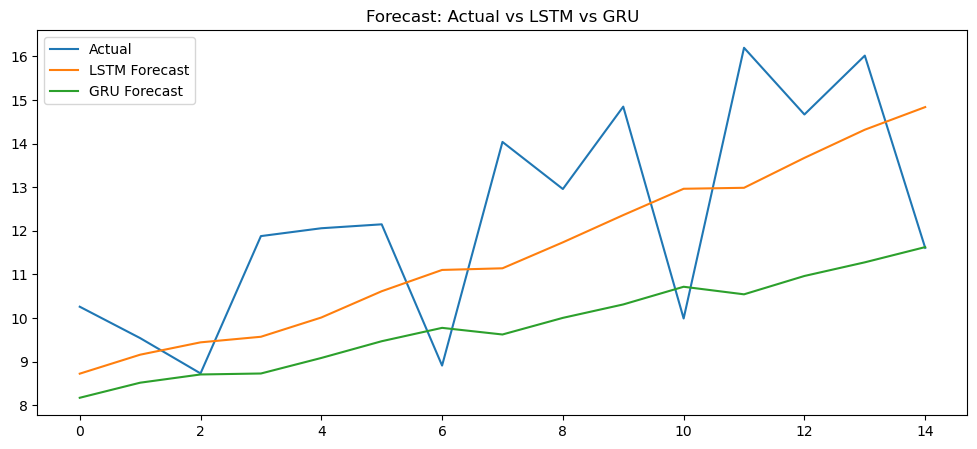

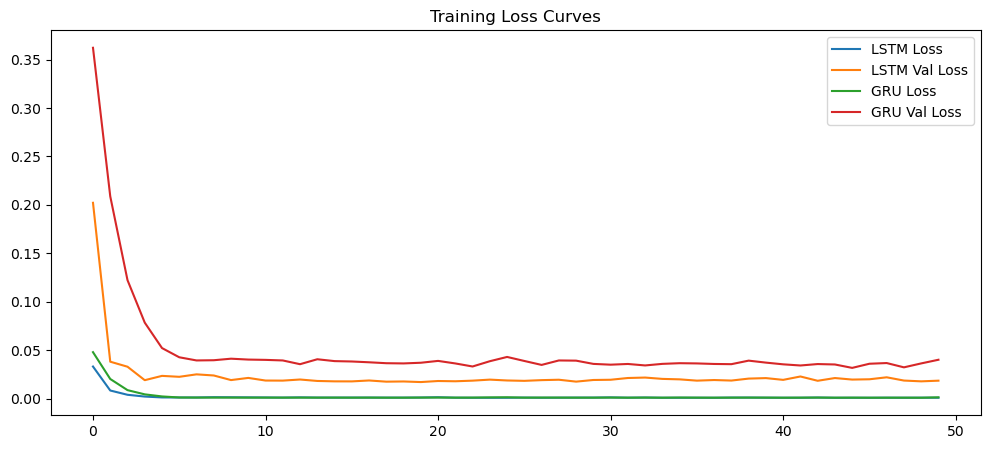

In [31]:
# Evaluation
print("LSTM RMSE:", np.sqrt(mean_squared_error(y_test_inv, lstm_pred)))
print("LSTM MAE:", mean_absolute_error(y_test_inv, lstm_pred))
print("GRU RMSE:", np.sqrt(mean_squared_error(y_test_inv, gru_pred)))
print("GRU MAE:", mean_absolute_error(y_test_inv, gru_pred))

# Plotting forecasts
plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label='Actual')
plt.plot(lstm_pred, label='LSTM Forecast')
plt.plot(gru_pred, label='GRU Forecast')
plt.legend()
plt.title("Forecast: Actual vs LSTM vs GRU")
plt.show()

# Plotting training losses
plt.figure(figsize=(12, 5))
plt.plot(history_lstm.history['loss'], label='LSTM Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')
plt.plot(history_gru.history['loss'], label='GRU Loss')
plt.plot(history_gru.history['val_loss'], label='GRU Val Loss')
plt.legend()
plt.title("Training Loss Curves")
plt.show()